# P13 - EDA des effectifs scolaires

Notebook EDA principal pour Rennes Metropole.

Objectifs:
- verifier la disponibilite des donnees
- controler la qualite des tables cles
- analyser les tendances temporelles et communales


In [1]:
from pathlib import Path
import sys

import pandas as pd
import plotly.express as px

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
else:
    sys.path.insert(0, '../../src')

from p13.db import read_sql


In [2]:
effectifs = read_sql('SELECT * FROM v_effectifs_commune_annee ORDER BY rentree, nom_commune')
demo = read_sql('SELECT code_insee, nom_commune, population FROM communes ORDER BY nom_commune')
stats = read_sql('SELECT code_insee, densite_2021, cat_0_14_2020, natalite_2022 FROM stats_communes')

print('effectifs:', effectifs.shape)
print('communes:', demo.shape)
print('stats_communes:', stats.shape)

effectifs.head()


effectifs: (688, 12)
communes: (43, 3)
stats_communes: (43, 4)


,rentree,code_insee,nom_commune,nb_classes,nb_eleves_total,nb_eleves_maternelle,nb_eleves_elementaire,nb_eleves_ecoles_mat,nb_eleves_ecoles_elem,nb_ecoles_rep,nb_ecoles_rep_plus,nb_ecoles
0,2009,35001,Acigné,30.0,768.0,281.0,487.0,188.0,353.0,0,0,3
1,2009,35024,Betton,40.0,1030.0,375.0,655.0,224.0,393.0,0,0,6
2,2009,35032,Bourgbarré,20.0,517.0,222.0,295.0,148.0,0.0,0,0,3
3,2009,35047,Bruz,66.0,1708.0,631.0,1077.0,394.0,218.0,0,0,8
4,2009,35039,Brécé,10.0,241.0,98.0,143.0,0.0,0.0,0,0,1


In [3]:
quality = pd.DataFrame({
    'table': ['effectifs', 'communes', 'stats_communes'],
    'rows': [len(effectifs), len(demo), len(stats)],
    'duplicates': [
        int(effectifs.duplicated(subset=['rentree', 'code_insee']).sum()),
        int(demo.duplicated(subset=['code_insee']).sum()),
        int(stats.duplicated(subset=['code_insee']).sum())
    ],
    'null_rate_pct': [
        round(effectifs.isna().mean().mean() * 100, 2),
        round(demo.isna().mean().mean() * 100, 2),
        round(stats.isna().mean().mean() * 100, 2)
    ]
})
quality


,table,rows,duplicates,null_rate_pct
0,effectifs,688,0,0.0
1,communes,43,0,0.0
2,stats_communes,43,0,0.0


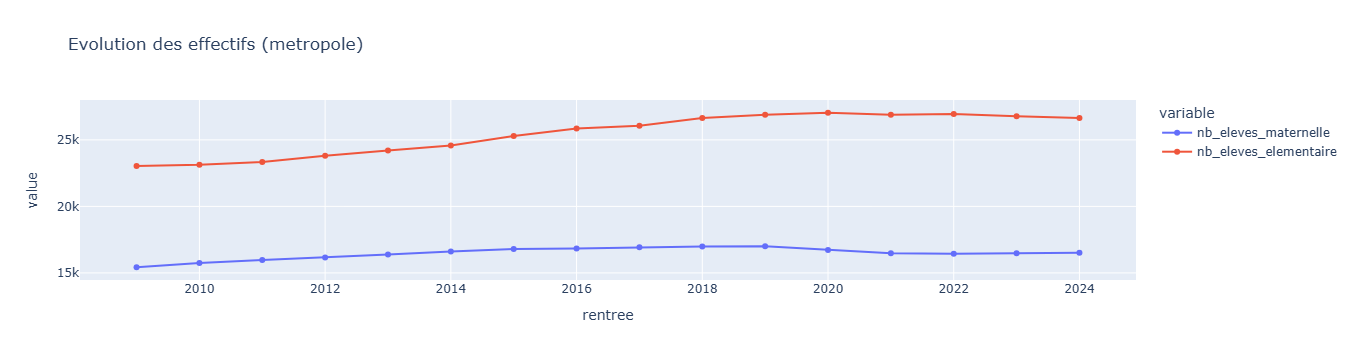

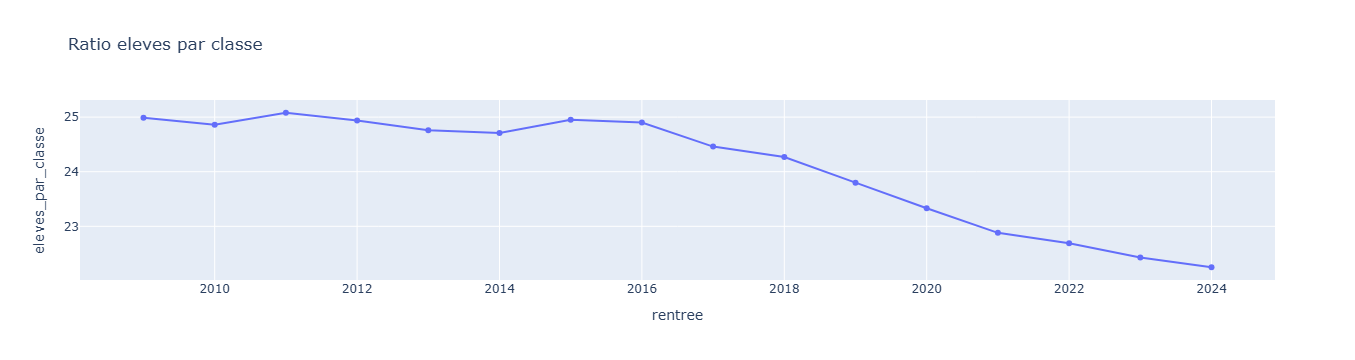

In [4]:
evo = (
    effectifs.groupby('rentree', as_index=False)
    .agg(
        nb_eleves_maternelle=('nb_eleves_maternelle', 'sum'),
        nb_eleves_elementaire=('nb_eleves_elementaire', 'sum'),
        nb_classes=('nb_classes', 'sum')
    )
)
evo['nb_eleves_total'] = evo['nb_eleves_maternelle'] + evo['nb_eleves_elementaire']
evo['eleves_par_classe'] = (evo['nb_eleves_total'] / evo['nb_classes']).round(2)

fig = px.line(
    evo,
    x='rentree',
    y=['nb_eleves_maternelle', 'nb_eleves_elementaire'],
    markers=True,
    title='Evolution des effectifs (metropole)'
)
fig.show()

fig_ratio = px.line(
    evo,
    x='rentree',
    y='eleves_par_classe',
    markers=True,
    title='Ratio eleves par classe'
)
fig_ratio.show()


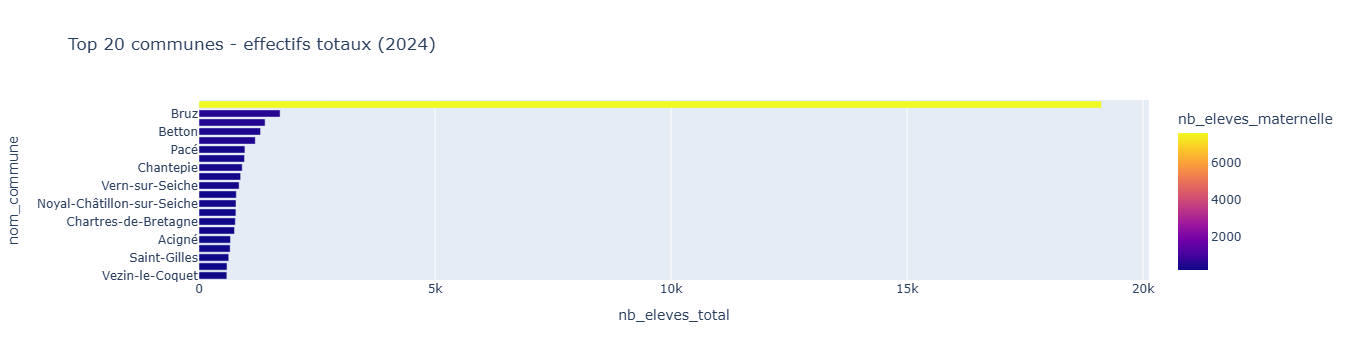

,nom_commune,nb_eleves_maternelle,nb_eleves_elementaire,nb_classes,nb_eleves_total
677,Rennes,7591.0,11387.0,900.0,19119.0
648,Bruz,591.0,1114.0,74.0,1718.0
651,Cesson-Sévigné,518.0,870.0,57.0,1400.0
646,Betton,431.0,863.0,54.0,1304.0
683,Saint-Jacques-de-la-Lande,478.0,714.0,53.0,1192.0
674,Pacé,322.0,651.0,41.0,973.0
666,Le Rheu,348.0,616.0,42.0,964.0
652,Chantepie,354.0,561.0,39.0,915.0
682,Saint-Grégoire,308.0,574.0,36.0,882.0
686,Vern-sur-Seiche,321.0,509.0,38.0,850.0


In [5]:
latest_year = int(effectifs['rentree'].max())
latest = effectifs[effectifs['rentree'] == latest_year].copy()
latest = latest.sort_values('nb_eleves_total', ascending=False).head(20)

fig_top = px.bar(
    latest.sort_values('nb_eleves_total'),
    x='nb_eleves_total',
    y='nom_commune',
    orientation='h',
    title=f'Top 20 communes - effectifs totaux ({latest_year})',
    color='nb_eleves_maternelle'
)
fig_top.show()

latest[['nom_commune', 'nb_eleves_maternelle', 'nb_eleves_elementaire', 'nb_classes', 'nb_eleves_total']]


## Prochaines analyses

- Notebook 02: explicabilite SHAP des modeles entraines
- Notebook 03: benchmark modeles et analyse d'erreurs
